# ChEMBL 36 — Exploratory Data Analysis

Joined 10K sample from core ChEMBL 36 tables: activities, assays, targets, molecules, compound structures & properties.

In [37]:
import polars as pl
import matplotlib.pyplot as plt

DATA_PATH = "chembl_36/chembl_36_joined_10k.parquet"

df = pl.read_parquet(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (50000, 102)


activity_id,assay_id,doc_id,record_id,molregno,standard_relation,standard_value,standard_units,standard_flag,standard_type,activity_comment,data_validity_comment,potential_duplicate,pchembl_value,bao_endpoint,uo_units,qudt_units,toid,upper_value,standard_upper_value,src_id,type,relation,value,units,text_value,standard_text_value,action_type,assay_doc_id,description,assay_type,assay_test_type,assay_category,assay_organism,assay_tax_id,assay_strain,assay_tissue,…,first_approval,oral,parenteral,topical,black_box_warning,natural_product,first_in_class,chirality,prodrug,inorganic_flag,usan_year,availability_type,usan_stem,polymer_flag,usan_substem,usan_stem_definition,withdrawn_flag,chemical_probe,orphan,veterinary,standard_inchi,standard_inchi_key,canonical_smiles,mw_freebase,alogp,hba,hbd,psa,rtb,ro3_pass,num_ro5_violations,full_mwt,aromatic_rings,heavy_atoms,qed_weighted,full_molformula,np_likeness_score
i64,i64,i64,i64,i64,str,f64,str,i64,str,str,str,i64,f64,str,str,str,f64,f64,null,i64,str,str,f64,str,str,str,str,i64,str,str,str,str,str,f64,str,str,…,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,str,i64,str,str,i64,i64,i64,i64,str,str,str,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,str,f64
2621830,501008,46734,757043,479236,null,null,null,0,"""Activity""","""Not Evaluated""",null,0,null,"""BAO_0000375""",null,null,null,null,null,1,"""Activity""",null,null,null,null,null,null,46734,"""Antidiabetic activity in lean …","""F""",null,null,"""Mus musculus""",10090.0,"""BALB/c""","""Blood""",…,null,0,0,0,0,0,-1,-1,-1,-1,null,-1.0,null,0,null,null,0,0,-1,-1,"""InChI=1S/C8H10ClN3/c9-7-4-2-1-…","""AKIBCPLFOPWWPF-UHFFFAOYSA-N""","""N=C(N)NCc1ccccc1Cl""",183.64,1.32,1.0,3.0,61.9,2.0,"""N""",0.0,183.64,1.0,12.0,0.48,"""C8H10ClN3""",-1.31
18065165,1664467,104503,2994184,2221402,""">""",10.0,"""ug ml-1""",0,"""Activity""",null,null,0,null,"""BAO_0000181""","""UO_0000274""","""http://www.openphacts.org/unit…",null,null,null,1,"""Activity""",""">""",10.0,"""ug ml-1""",null,null,null,104503,"""Cytotoxicity against African g…","""A""",null,null,"""Chlorocebus sabaeus""",60711.0,null,null,…,null,0,0,0,0,0,-1,-1,-1,-1,null,-1.0,null,0,null,null,0,0,-1,-1,"""InChI=1S/C41H44N8O6/c1-41(2,3)…","""LSBHRINXMONTAX-AFEGWXKPSA-N""","""COC(=O)[C@H](Cc1c[nH]c(-c2cccc…",744.85,5.01,8.0,6.0,195.98,14.0,"""N""",3.0,744.85,6.0,55.0,0.08,"""C41H44N8O6""",-0.3
12199953,885401,66940,1757494,11305,"""=""",62.0,"""%""",0,"""Activity""",null,null,0,null,"""BAO_0001103""","""UO_0000187""","""http://qudt.org/vocab/unit#Per…",null,null,null,1,"""Activity""","""=""",62.0,"""%""",null,null,null,66940,"""Inhibition of HDAC6 using Fluo…","""B""",null,null,null,null,null,null,…,2006.0,1,0,0,0,1,0,2,0,0,2005.0,1.0,"""-stat""",0,"""-stat (-inostat)""","""enzyme inhibitors: histone dea…",0,0,0,0,"""InChI=1S/C14H20N2O3/c17-13(15-…","""WAEXFXRVDQXREF-UHFFFAOYSA-N""","""O=C(CCCCCCC(=O)Nc1ccccc1)NO""",264.32,2.47,3.0,3.0,78.43,8.0,"""N""",0.0,264.32,1.0,19.0,0.38,"""C14H20N2O3""",-0.62
13228916,955045,51886,1878422,650126,"""=""",27444.7,"""nM""",1,"""IC50""",null,null,0,4.56,"""BAO_0000190""","""UO_0000065""","""http://www.openphacts.org/unit…",null,null,null,5,"""IC50""","""=""",27.444698,"""uM""",null,null,null,51886,"""SANGER: Inhibition of human MH…","""F""","""In vitro""",null,"""Homo sapiens""",9606.0,null,null,…,2013.0,1,0,0,0,0,0,1,0,0,2010.0,1.0,"""-tinib""",0,"""-tinib""","""tyrosine kinase inhibitors""",0,1,0,0,"""InChI=1S/C24H25ClFN5O3/c1-31(2…","""ULXXDDBFHOBEHA-CWDCEQMOSA-N""","""CN(C)C/C=C/C(=O)Nc1cc2c(Nc3ccc…",485.95,4.39,7.0,2.0,88.61,8.0,"""N""",0.0,485.95,3.0,34.0,0.46,"""C24H25ClFN5O3""",-1.14
23508214,2144902,121406,3751235,2696799,"""=""",0.3,null,0,"""Z score""",null,null,0,null,"""BAO_0000179""",null,null,null,null,null,60,"""Z score""","""=""",0.3,null,null,null,null,121406,"""Primary screen in NF54 nanoGlo…","""F""","""In vitro""",null,"""Plasmodium falciparum""",5833.0,"""NF54""",null,…,null,0,0,0,0,0,-1,-1,-1,-1,null,-1.0,null,0,null,null,0,0,-1,-1

## 0. Filter to human targets only

## 1. Data overview

In [38]:
# Check organism distribution before filtering
print("Top target organisms:")
print(df.group_by("target_organism").agg(pl.len().alias("count")).sort("count", descending=True).head(10))

n_before = len(df)
df = df.filter(pl.col("target_organism") == "Homo sapiens")
n_after = len(df)
print(f"\nFiltered to Homo sapiens only:")
print(f"  Before: {n_before:,}")
print(f"  After:  {n_after:,}")
print(f"  Removed: {n_before - n_after:,} non-human rows")

Top target organisms:
shape: (10, 2)
┌─────────────────────────────────┬───────┐
│ target_organism                 ┆ count │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞═════════════════════════════════╪═══════╡
│ Homo sapiens                    ┆ 28394 │
│ null                            ┆ 6959  │
│ Rattus norvegicus               ┆ 2623  │
│ Plasmodium falciparum           ┆ 2036  │
│ Mus musculus                    ┆ 1545  │
│ Mycobacterium tuberculosis (st… ┆ 601   │
│ Staphylococcus aureus           ┆ 520   │
│ Mycobacterium tuberculosis      ┆ 460   │
│ Plasmodium berghei              ┆ 387   │
│ Escherichia coli                ┆ 317   │
└─────────────────────────────────┴───────┘

Filtered to Homo sapiens only:
  Before: 50,000
  After:  28,394
  Removed: 21,606 non-human rows


In [39]:
df.describe()

statistic,activity_id,assay_id,doc_id,record_id,molregno,standard_relation,standard_value,standard_units,standard_flag,standard_type,activity_comment,data_validity_comment,potential_duplicate,pchembl_value,bao_endpoint,uo_units,qudt_units,toid,upper_value,standard_upper_value,src_id,type,relation,value,units,text_value,standard_text_value,action_type,assay_doc_id,description,assay_type,assay_test_type,assay_category,assay_organism,assay_tax_id,assay_strain,…,first_approval,oral,parenteral,topical,black_box_warning,natural_product,first_in_class,chirality,prodrug,inorganic_flag,usan_year,availability_type,usan_stem,polymer_flag,usan_substem,usan_stem_definition,withdrawn_flag,chemical_probe,orphan,veterinary,standard_inchi,standard_inchi_key,canonical_smiles,mw_freebase,alogp,hba,hbd,psa,rtb,ro3_pass,num_ro5_violations,full_mwt,aromatic_rings,heavy_atoms,qed_weighted,full_molformula,np_likeness_score
str,f64,f64,f64,f64,f64,str,f64,str,f64,str,str,str,f64,f64,str,str,str,f64,f64,f64,f64,str,str,f64,str,str,str,str,f64,str,str,str,str,str,f64,str,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,str,f64,f64,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,str,f64
"""count""",28394.0,28394.0,28394.0,28394.0,28394.0,"""17485""",24066.0,"""25332""",28394.0,"""28394""","""19207""","""279""",28394.0,6798.0,"""28394""","""23688""","""23674""",940.0,60.0,0.0,28394.0,"""28394""","""17485""",24066.0,"""20912""","""352""","""352""","""729""",28394.0,"""28394""","""28394""","""3691""","""13362""","""17230""",17364.0,"""0""",…,1099.0,28394.0,28394.0,28394.0,28394.0,28394.0,28394.0,28394.0,28394.0,28394.0,1269.0,27499.0,"""1292""",28394.0,"""1292""","""1292""",28394.0,28394.0,28394.0,28394.0,"""28184""","""28184""","""28184""",28283.0,27676.0,27676.0,27676.0,27676.0,27676.0,"""27676""",27676.0,28283.0,27676.0,27676.0,27676.0,"""28283""",27676.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,"""10909""",4328.0,"""3062""",0.0,"""0""","""9187""","""28115""",0.0,21596.0,"""0""","""4706""","""4720""",27454.0,28334.0,28394.0,0.0,"""0""","""10909""",4328.0,"""7482""","""28042""","""28042""","""27665""",0.0,"""0""","""0""","""24703""","""15032""","""11164""",11030.0,"""28394""",…,27295.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,27125.0,895.0,"""27102""",0.0,"""27102""","""27102""",0.0,0.0,0.0,0.0,"""210""","""210""","""210""",111.0,718.0,718.0,718.0,718.0,718.0,"""718""",718.0,111.0,718.0,718.0,718.0,"""111""",718.0
"""mean""",1.4616e7,1.3518e6,80097.06195,2.3209e6,1.5047e6,null,1.6896e11,null,0.721667,null,null,null,0.02166,6.193997,null,null,null,28943.03617,253.705317,null,14.901669,null,null,4707.785557,null,null,null,null,79782.683806,null,null,null,null,null,9937.176457,null,…,1989.169245,0.028879,0.013137,0.007149,0.014193,0.090899,-0.925231,-0.827287,-0.925019,-0.928083,1992.703704,-0.927816,null,0.0,null,null,0.002536,0.016623,-0.926921,-0.927943,null,null,null,420.551369,3.585112,5.521752,1.578588,83.679037,5.36407,null,0.418702,424.458149,2.670509,28.818579,0.531658,null,-0.850141
"""std""",8.7562e6,767190.476368,36879.162335,1.3201e6,937976.399976,null,2.5666e13,null,0.448186,null,null,null,0.145572,1.431484,null,null,null,9078.655807,700.528687,null,17.523201,null,null,527535.341824,null,null,null,null,36505.07761,null,null,null,null,null,2883.973542,null,…,20.236906,0.16747,0.113862,0.084253,0.118289,0.287471,0.274554,0.648073,0.275649,0.259307,17.936942,0.387534,null,0.0,null,null,0.050293,0.127857,0.265628,0.260082,null,null,null,189.417389,1.757677,2.424252,1.345447,39.218767,3.299567,null,0.718929,190.175573,1.25741,8.676338,0.204347,null,1.01852
"""min""",32096.0,663.0,185.0,288.0,115.0,"""<""",-141.0,"""%""",0.0,"""% Control""","""% Binding""","""Manually validated""",0.0,2.95,"""BAO_0000034""","""UO_0000017""","""http://qudt.org/vocab/unit#Deg…",14115.0,0.199,null,1.0,"""% Control""","""<""",-141.0,"""%""","""Metabolite_Notdetected""","""Metabolite_Notdetected""","""ACTIVATOR""",185.0,"""3H-SB222200 Binding Compe

In [40]:
print(f"Columns ({len(df.columns)}):")
for col in df.columns:
    print(f"  {col:40s} {df[col].dtype}")

Columns (102):
  activity_id                              Int64
  assay_id                                 Int64
  doc_id                                   Int64
  record_id                                Int64
  molregno                                 Int64
  standard_relation                        String
  standard_value                           Float64
  standard_units                           String
  standard_flag                            Int64
  standard_type                            String
  activity_comment                         String
  data_validity_comment                    String
  potential_duplicate                      Int64
  pchembl_value                            Float64
  bao_endpoint                             String
  uo_units                                 String
  qudt_units                               String
  toid                                     Float64
  upper_value                              Float64
  standard_upper_value                

## 0b. Filter by confidence score

Keep only rows with `confidence_score > 4` (direct protein target or better).

In [41]:
# Check confidence_score distribution before filtering
print("Confidence score distribution:")
print(df.group_by("confidence_score").agg(pl.len().alias("count")).sort("confidence_score"))

n_before = len(df)
df = df.filter(pl.col("confidence_score") > 4)
n_after = len(df)
print(f"\nFiltered to confidence_score > 4:")
print(f"  Before: {n_before:,}")
print(f"  After:  {n_after:,}")
print(f"  Removed: {n_before - n_after:,} low-confidence rows")

Confidence score distribution:
shape: (9, 2)
┌──────────────────┬───────┐
│ confidence_score ┆ count │
│ ---              ┆ ---   │
│ i64              ┆ u32   │
╞══════════════════╪═══════╡
│ 1                ┆ 10353 │
│ 2                ┆ 25    │
│ 3                ┆ 161   │
│ 4                ┆ 190   │
│ 5                ┆ 318   │
│ 6                ┆ 206   │
│ 7                ┆ 230   │
│ 8                ┆ 5993  │
│ 9                ┆ 10918 │
└──────────────────┴───────┘

Filtered to confidence_score > 4:
  Before: 28,394
  After:  17,665
  Removed: 10,729 low-confidence rows


## 2. Deduplication by molecule

In [42]:
n_before = len(df)
df = df.unique(subset=["molregno"], keep="last")
n_after = len(df)
print(f"Before: {n_before:,} rows")
print(f"After:  {n_after:,} rows")
print(f"Removed: {n_before - n_after:,} duplicates")

Before: 17,665 rows
After:  16,711 rows
Removed: 954 duplicates


## 3. Null analysis

In [43]:
nulls = df.null_count().to_dicts()[0]
sorted_nulls = {k: v for k, v in sorted(nulls.items(), key=lambda x: x[1], reverse=True) if v > 0}

print(f"Columns with nulls: {len(sorted_nulls)} / {len(df.columns)}\n")
for col, count in sorted_nulls.items():
    pct = count / len(df) * 100
    print(f"  {col:40s} {count:>6,} ({pct:5.1f}%)")

Columns with nulls: 56 / 102

  standard_upper_value                     16,711 (100.0%)
  assay_strain                             16,711 (100.0%)
  assay_group                              16,709 (100.0%)
  toid                                     16,675 ( 99.8%)
  upper_value                              16,671 ( 99.8%)
  tissue_id                                16,598 ( 99.3%)
  assay_tissue                             16,582 ( 99.2%)
  data_validity_comment                    16,562 ( 99.1%)
  variant_id                               16,550 ( 99.0%)
  text_value                               16,445 ( 98.4%)
  standard_text_value                      16,445 ( 98.4%)
  assay_subcellular_fraction               16,376 ( 98.0%)
  first_approval                           16,245 ( 97.2%)
  usan_year                                16,203 ( 97.0%)
  usan_stem                                16,187 ( 96.9%)
  usan_substem                             16,187 ( 96.9%)
  usan_stem_definition    

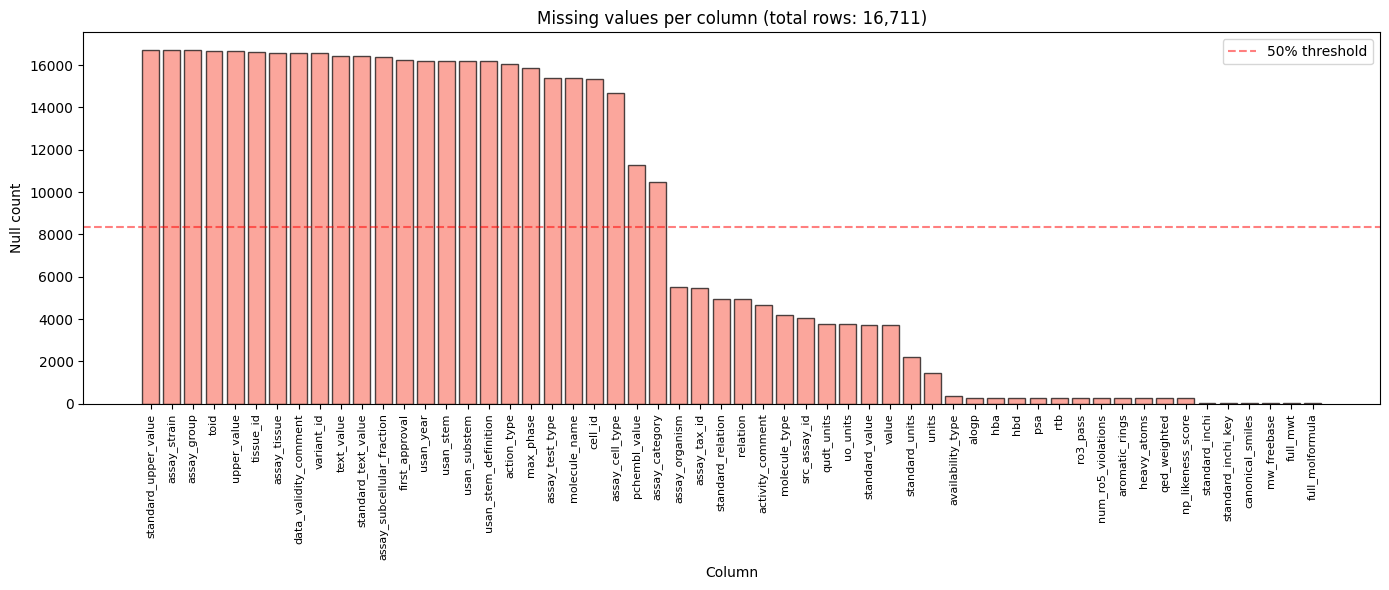

In [44]:
columns = list(sorted_nulls.keys())
counts = list(sorted_nulls.values())

plt.figure(figsize=(14, 6))
plt.bar(columns, counts, color="salmon", edgecolor="black", alpha=0.7)
plt.axhline(y=len(df) * 0.5, color="red", linestyle="--", alpha=0.5, label="50% threshold")
plt.title(f"Missing values per column (total rows: {len(df):,})")
plt.xlabel("Column")
plt.ylabel("Null count")
plt.xticks(rotation=90, fontsize=8)
plt.legend()
plt.tight_layout()
plt.show()

## 4. Unit checking

In [45]:
unit_dist = (
    df.group_by("standard_units")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
)
print(f"Unique units: {len(unit_dist)}")
print(f"Rows with missing units: {df['standard_units'].null_count():,}\n")
unit_dist

Unique units: 52
Rows with missing units: 2,200



standard_units,count
str,u32
"""nM""",11181
null,2200
"""%""",1683
"""s-1""",1457
"""C""",41
…,…
"""/s""",1
"""10^6/Ms""",1
"""10'6/M/s""",1


## 5. Unit imputation

Fill missing `standard_units` with "nM" when `standard_value` exists and falls in 0.01–1,000,000 range.

In [46]:
missing_before = df["standard_units"].null_count()

mask_missing = pl.col("standard_units").is_null() & pl.col("standard_value").is_not_null()
mask_range = (pl.col("standard_value") >= 0.01) & (pl.col("standard_value") <= 1e6)

df = df.with_columns([
    pl.when(mask_missing & mask_range)
    .then(pl.lit("nM"))
    .otherwise(pl.col("standard_units"))
    .alias("standard_units"),

    pl.when(mask_missing & mask_range)
    .then(pl.lit(True))
    .otherwise(pl.lit(False))
    .alias("units_imputed"),
])

missing_after = df["standard_units"].null_count()
imputed = df.filter(pl.col("units_imputed")).height

print(f"Missing units before: {missing_before:,}")
print(f"Missing units after:  {missing_after:,}")
print(f"Imputed as nM:        {imputed:,}")

Missing units before: 2,200
Missing units after:  2,055
Imputed as nM:        145


## 6. Unit standardization

Convert all concentration units to nM. Drop rows with non-convertible units (%, ug.mL-1, etc.).

In [47]:
convertible_units = ["nM", "uM", "mM", "pM", "fM", "M"]
n_before = len(df)

# Drop rows with non-convertible units (%, ug.mL-1, etc.)
df = df.filter(pl.col("standard_units").is_in(convertible_units))

# Convert all values to nM in a new column
df = df.with_columns(
    pl.when(pl.col("standard_units") == "uM").then(pl.col("standard_value") * 1_000)
    .when(pl.col("standard_units") == "mM").then(pl.col("standard_value") * 1_000_000)
    .when(pl.col("standard_units") == "pM").then(pl.col("standard_value") * 0.001)
    .when(pl.col("standard_units") == "fM").then(pl.col("standard_value") * 0.000001)
    .when(pl.col("standard_units") == "M").then(pl.col("standard_value") * 1e9)
    .otherwise(pl.col("standard_value"))
    .alias("standard_value_nM"),
)

n_after = len(df)
print(f"Rows before: {n_before:,}")
print(f"Rows after:  {n_after:,}")
print(f"Dropped (non-convertible units): {n_before - n_after:,}")
print(f"\nOriginal unit breakdown (all now converted to nM):")
print(df.group_by("standard_units").agg(pl.len().alias("count")).sort("count", descending=True))
print(f"\nstandard_value_nM stats:")
print(df["standard_value_nM"].describe())

Rows before: 16,711
Rows after:  11,361
Dropped (non-convertible units): 5,350

Original unit breakdown (all now converted to nM):
shape: (4, 2)
┌────────────────┬───────┐
│ standard_units ┆ count │
│ ---            ┆ ---   │
│ str            ┆ u32   │
╞════════════════╪═══════╡
│ nM             ┆ 11326 │
│ uM             ┆ 31    │
│ mM             ┆ 2     │
│ M              ┆ 2     │
└────────────────┴───────┘

standard_value_nM stats:
shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 11341.0   │
│ null_count ┆ 20.0      │
│ mean       ┆ 3.5156e11 │
│ std        ┆ 3.7383e13 │
│ min        ┆ 0.0       │
│ 25%        ┆ 280.0     │
│ 50%        ┆ 8714.0    │
│ 75%        ┆ 28183.8   │
│ max        ┆ 3.9811e15 │
└────────────┴───────────┘


## 7. Outlier detection

Use log10 scale + IQR method to detect outliers in `standard_value_nM`. Cross-reference with ChEMBL's `data_validity_comment` flag.

In [48]:
import numpy as np

# Work on log10 scale (bioactivity data is log-normal)
df_valid = df.filter(pl.col("standard_value_nM").is_not_null() & (pl.col("standard_value_nM") > 0))

log_values = np.log10(df_valid["standard_value_nM"].to_numpy())
q1, q3 = np.percentile(log_values, [25, 75])
iqr = q3 - q1
lower_bound = 10 ** (q1 - 1.5 * iqr)
upper_bound = 10 ** (q3 + 1.5 * iqr)

print(f"IQR on log10 scale: Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")
print(f"Outlier bounds (nM): [{lower_bound:.4f}, {upper_bound:,.0f}]")

# Flag outliers
df = df.with_columns(
    ((pl.col("standard_value_nM") < lower_bound) | (pl.col("standard_value_nM") > upper_bound))
    .alias("is_outlier")
)

n_outliers = df.filter(pl.col("is_outlier")).height
print(f"\nOutliers detected: {n_outliers:,} / {len(df):,} ({n_outliers/len(df)*100:.1f}%)")

# Cross-reference with data_validity_comment
print("\ndata_validity_comment among outliers:")
print(
    df.filter(pl.col("is_outlier"))
    .group_by("data_validity_comment")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
)

print("\ndata_validity_comment among non-outliers:")
print(
    df.filter(~pl.col("is_outlier"))
    .group_by("data_validity_comment")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
)

IQR on log10 scale: Q1=2.45, Q3=4.45, IQR=2.00
Outlier bounds (nM): [0.2773, 28,461,765]

Outliers detected: 125 / 11,361 (1.1%)

data_validity_comment among outliers:
shape: (3, 2)
┌───────────────────────────────┬───────┐
│ data_validity_comment         ┆ count │
│ ---                           ┆ ---   │
│ str                           ┆ u32   │
╞═══════════════════════════════╪═══════╡
│ null                          ┆ 106   │
│ Outside typical range         ┆ 18    │
│ Potential transcription error ┆ 1     │
└───────────────────────────────┴───────┘

data_validity_comment among non-outliers:
shape: (4, 2)
┌───────────────────────────────┬───────┐
│ data_validity_comment         ┆ count │
│ ---                           ┆ ---   │
│ str                           ┆ u32   │
╞═══════════════════════════════╪═══════╡
│ null                          ┆ 11115 │
│ Outside typical range         ┆ 94    │
│ Potential transcription error ┆ 4     │
│ Manually validated            ┆ 3     │
└────

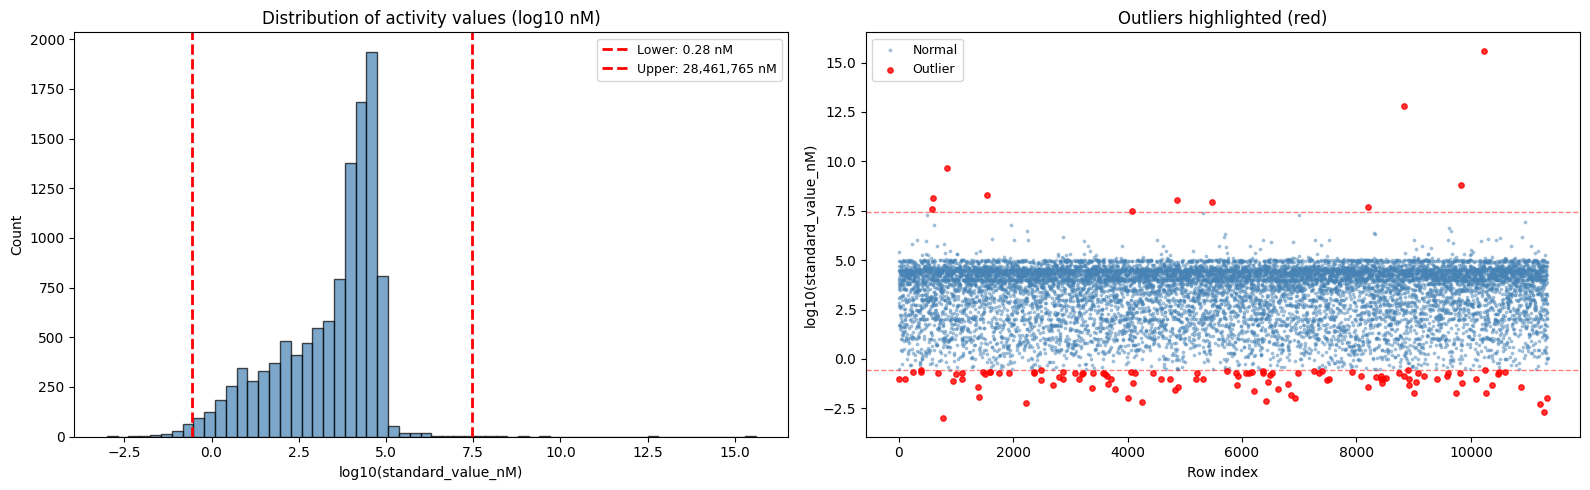

In [49]:
# Chart 1: Histogram on log10 scale with outlier bounds
vals = df.filter(pl.col("standard_value_nM").is_not_null() & (pl.col("standard_value_nM") > 0))
log_vals = np.log10(vals["standard_value_nM"].to_numpy())
outlier_flags = vals["is_outlier"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: histogram with IQR bounds
axes[0].hist(log_vals, bins=60, color="steelblue", edgecolor="black", alpha=0.7)
axes[0].axvline(np.log10(lower_bound), color="red", linestyle="--", lw=2, label=f"Lower: {lower_bound:.2f} nM")
axes[0].axvline(np.log10(upper_bound), color="red", linestyle="--", lw=2, label=f"Upper: {upper_bound:,.0f} nM")
axes[0].set_xlabel("log10(standard_value_nM)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of activity values (log10 nM)")
axes[0].legend(fontsize=9)

# Right: scatter — index vs log10 value, outliers in red
axes[1].scatter(
    np.where(~outlier_flags)[0], log_vals[~outlier_flags],
    s=3, alpha=0.4, color="steelblue", label="Normal"
)
axes[1].scatter(
    np.where(outlier_flags)[0], log_vals[outlier_flags],
    s=15, alpha=0.8, color="red", label="Outlier", zorder=5
)
axes[1].axhline(np.log10(lower_bound), color="red", linestyle="--", lw=1, alpha=0.5)
axes[1].axhline(np.log10(upper_bound), color="red", linestyle="--", lw=1, alpha=0.5)
axes[1].set_xlabel("Row index")
axes[1].set_ylabel("log10(standard_value_nM)")
axes[1].set_title("Outliers highlighted (red)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [50]:
# Remove outliers
n_before = len(df)
df = df.filter(~pl.col("is_outlier"))
n_after = len(df)
print(f"Removed {n_before - n_after:,} outliers")
print(f"Rows remaining: {n_after:,}")

Removed 145 outliers
Rows remaining: 11,216


## 8. Compute pIC50

`pIC50 = -log10(value_nM * 1e-9) = 9 - log10(value_nM)`

Compute new column, compare with ChEMBL's `pchembl_value`, then drop the original.

In [51]:
# Compute pIC50 from standard_value_nM
df = df.with_columns(
    pl.when(pl.col("standard_value_nM").is_not_null() & (pl.col("standard_value_nM") > 0))
    .then(-(pl.col("standard_value_nM") * 1e-9).log(base=10))
    .otherwise(None)
    .alias("pIC50")
)

print(f"pIC50 computed: {df['pIC50'].drop_nulls().len():,} / {len(df):,} rows")
print(f"\npIC50 stats:")
print(df["pIC50"].describe())

pIC50 computed: 11,216 / 11,216 rows

pIC50 stats:
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 11216.0  │
│ null_count ┆ 0.0      │
│ mean       ┆ 5.613012 │
│ std        ┆ 1.372905 │
│ min        ┆ 1.59     │
│ 25%        ┆ 4.55     │
│ 50%        ┆ 5.05     │
│ 75%        ┆ 6.500038 │
│ max        ┆ 9.552842 │
└────────────┴──────────┘


In [52]:
# Compare computed pIC50 with ChEMBL's pchembl_value
df_cmp = df.filter(pl.col("pIC50").is_not_null() & pl.col("pchembl_value").is_not_null())

df_cmp = df_cmp.with_columns(
    (pl.col("pIC50") - pl.col("pchembl_value")).abs().alias("abs_diff")
)

corr = df_cmp.select(pl.corr("pIC50", "pchembl_value")).item()
mean_diff = df_cmp["abs_diff"].mean()
median_diff = df_cmp["abs_diff"].median()
max_diff = df_cmp["abs_diff"].max()

print(f"Comparable rows: {len(df_cmp):,}")
print(f"Pearson correlation: {corr:.4f}")
print(f"Mean abs difference: {mean_diff:.4f}")
print(f"Median abs difference: {median_diff:.4f}")
print(f"Max abs difference: {max_diff:.4f}")

# Preview side by side
df_cmp.select(["molregno", "standard_value_nM", "pIC50", "pchembl_value", "abs_diff"]).head(10)

Comparable rows: 5,351
Pearson correlation: 1.0000
Mean abs difference: 0.0016
Median abs difference: 0.0010
Max abs difference: 0.0055


molregno,standard_value_nM,pIC50,pchembl_value,abs_diff
i64,f64,f64,f64,f64
1441751,0.3,9.522879,9.52,0.002879
1362710,700.0,6.154902,6.16,0.005098
3071345,10383.0,4.983677,4.98,0.003677
2948273,3362.0,5.473402,5.47,0.003402
2749974,13110.0,4.882397,4.88,0.002397
867650,31622.8,4.5,4.5,3.2134e-7
2295500,1258.93,5.899998,5.9,0.000002
2958119,4832.0,5.315873,5.32,0.004127
19278,1365.6,5.864676,5.87,0.005324


In [53]:
# Drop original pchembl_value, keep our computed pIC50
df = df.drop("pchembl_value")
print(f"Dropped 'pchembl_value'. Keeping computed 'pIC50'.")
print(f"Final shape: {df.shape}")
df.select(["molregno", "standard_value_nM", "pIC50"]).head(10)

Dropped 'pchembl_value'. Keeping computed 'pIC50'.
Final shape: (11216, 105)


molregno,standard_value_nM,pIC50
i64,f64,f64
1441751,0.3,9.522879
1683617,29092.9,4.536213
819269,7079.5,5.149997
1362710,700.0,6.154902
3071345,10383.0,4.983677
3142520,500.0,6.30103
2948273,3362.0,5.473402
2749974,13110.0,4.882397
2987073,50.0,7.30103


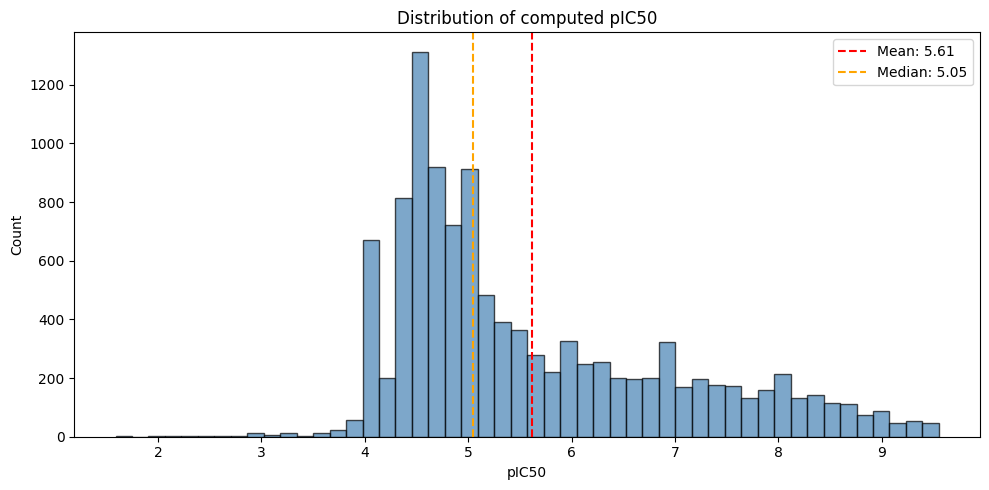

In [54]:
pIC50_vals = df["pIC50"].drop_nulls().to_numpy()

plt.figure(figsize=(10, 5))
plt.hist(pIC50_vals, bins=50, color="steelblue", edgecolor="black", alpha=0.7)
plt.axvline(np.mean(pIC50_vals), color="red", linestyle="--", lw=1.5, label=f"Mean: {np.mean(pIC50_vals):.2f}")
plt.axvline(np.median(pIC50_vals), color="orange", linestyle="--", lw=1.5, label=f"Median: {np.median(pIC50_vals):.2f}")
plt.xlabel("pIC50")
plt.ylabel("Count")
plt.title("Distribution of computed pIC50")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Correlation analysis

Pearson correlation heatmap for all numeric columns. Identify highly correlated pairs (|r| > 0.9) that may be redundant.

In [55]:
import seaborn as sns
import pandas as pd

# Select numeric columns only
numeric_cols = [c for c in df.columns if df[c].dtype in (pl.Int8, pl.Int16, pl.Int32, pl.Int64,
                                                          pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
                                                          pl.Float32, pl.Float64)]

print(f"Numeric columns: {len(numeric_cols)}")

# Compute correlation matrix via pandas (handles nulls gracefully)
corr_pd = df.select(numeric_cols).to_pandas().corr()

# Heatmap
plt.figure(figsize=(18, 15))
sns.heatmap(corr_pd, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.3, annot_kws={"size": 6},
            cbar_kws={"shrink": 0.8})
plt.title("Pearson correlation matrix (all numeric columns)")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [ ]:
# Find highly correlated pairs (|r| > 0.8)
THRESHOLD = 0.8

pairs = []
for i in range(len(corr_pd.columns)):
    for j in range(i + 1, len(corr_pd.columns)):
        r = corr_pd.iloc[i, j]
        if abs(r) > THRESHOLD:
            pairs.append((corr_pd.columns[i], corr_pd.columns[j], round(r, 3)))

pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print(f"Highly correlated pairs (|r| > {THRESHOLD}):\n")
for col1, col2, r in pairs:
    print(f"  {r:+.3f}  {col1}  <->  {col2}")

NameError: name 'corr_pd' is not defined

## 10. Drop redundant columns

Drop highly correlated, ID-only, and redundant columns. Keep what's needed for modeling.

In [56]:
cols_before = len(df.columns)

# Highly correlated / redundant
DROP_CORRELATED = [
    "full_mwt",          # ~1.0 corr with mw_freebase
    "heavy_atoms",       # ~0.95 corr with mw_freebase
    "num_ro5_violations", # derived from hba/hbd/mw/alogp
    "standard_value",    # replaced by standard_value_nM
    "value",             # raw duplicate of standard_value
    "standard_value_nM", # replaced by pIC50
    "np_likeness_score", # niche, rarely useful
]

# ID / foreign key columns (no modeling value)
DROP_IDS = [
    "assay_id", "doc_id", "record_id", "assay_doc_id", "assay_src_id",
    "src_id", "tid", "cell_id", "tissue_id", "variant_id", "toid",
    "activity_id", "src_assay_id", "targcomp_id",
]

# Metadata / flags no longer needed
DROP_META = [
    "standard_flag", "potential_duplicate", "data_validity_comment",
    "is_outlier", "units_imputed",
    "bao_endpoint", "uo_units", "qudt_units", "bao_format",
    "standard_upper_value", "upper_value",
    "standard_relation", "relation", "type",
    "standard_units", "units", "standard_text_value", "text_value",
    "activity_comment", "action_type",
    "assay_test_type", "assay_category", "assay_strain",
    "assay_subcellular_fraction", "assay_tissue", "assay_cell_type",
    "assay_group", "aidx", "curated_by", "relationship_type",
    "confidence_score", "assay_chembl_id",
    "target_tax_id", "assay_tax_id", "species_group_flag",
    "standard_inchi",  # keep standard_inchi_key instead
    "full_molformula",
    # molecule metadata not needed for modeling
    "dosed_ingredient", "structure_type", "first_approval",
    "oral", "parenteral", "topical", "black_box_warning",
    "natural_product", "first_in_class", "chirality", "prodrug",
    "inorganic_flag", "usan_year", "availability_type",
    "usan_stem", "polymer_flag", "usan_substem", "usan_stem_definition",
    "withdrawn_flag", "chemical_probe", "orphan", "veterinary",
    "molecule_name", "molecule_chembl_id",
    "target_organism",  # already filtered to Homo sapiens
    "assay_organism",   # assay-level organism
    "description",      # assay description text
    "assay_type",       # assay metadata
    "max_phase", "therapeutic_flag",
    "ro3_pass",
]

to_drop = [c for c in DROP_CORRELATED + DROP_IDS + DROP_META if c in df.columns]
df = df.drop(to_drop)

cols_after = len(df.columns)
print(f"Dropped {cols_before - cols_after} columns ({cols_before} -> {cols_after})")
print(f"\nRemaining columns ({cols_after}):")
for col in df.columns:
    print(f"  {col:40s} {df[col].dtype}")

Dropped 88 columns (105 -> 17)

Remaining columns (17):
  molregno                                 Int64
  standard_type                            String
  target_type                              String
  target_name                              String
  target_chembl_id                         String
  molecule_type                            String
  standard_inchi_key                       String
  canonical_smiles                         String
  mw_freebase                              Float64
  alogp                                    Float64
  hba                                      Float64
  hbd                                      Float64
  psa                                      Float64
  rtb                                      Float64
  aromatic_rings                           Float64
  qed_weighted                             Float64
  pIC50                                    Float64


## 11. Feature distributions

Histograms of the 8 molecular descriptors used for modeling.

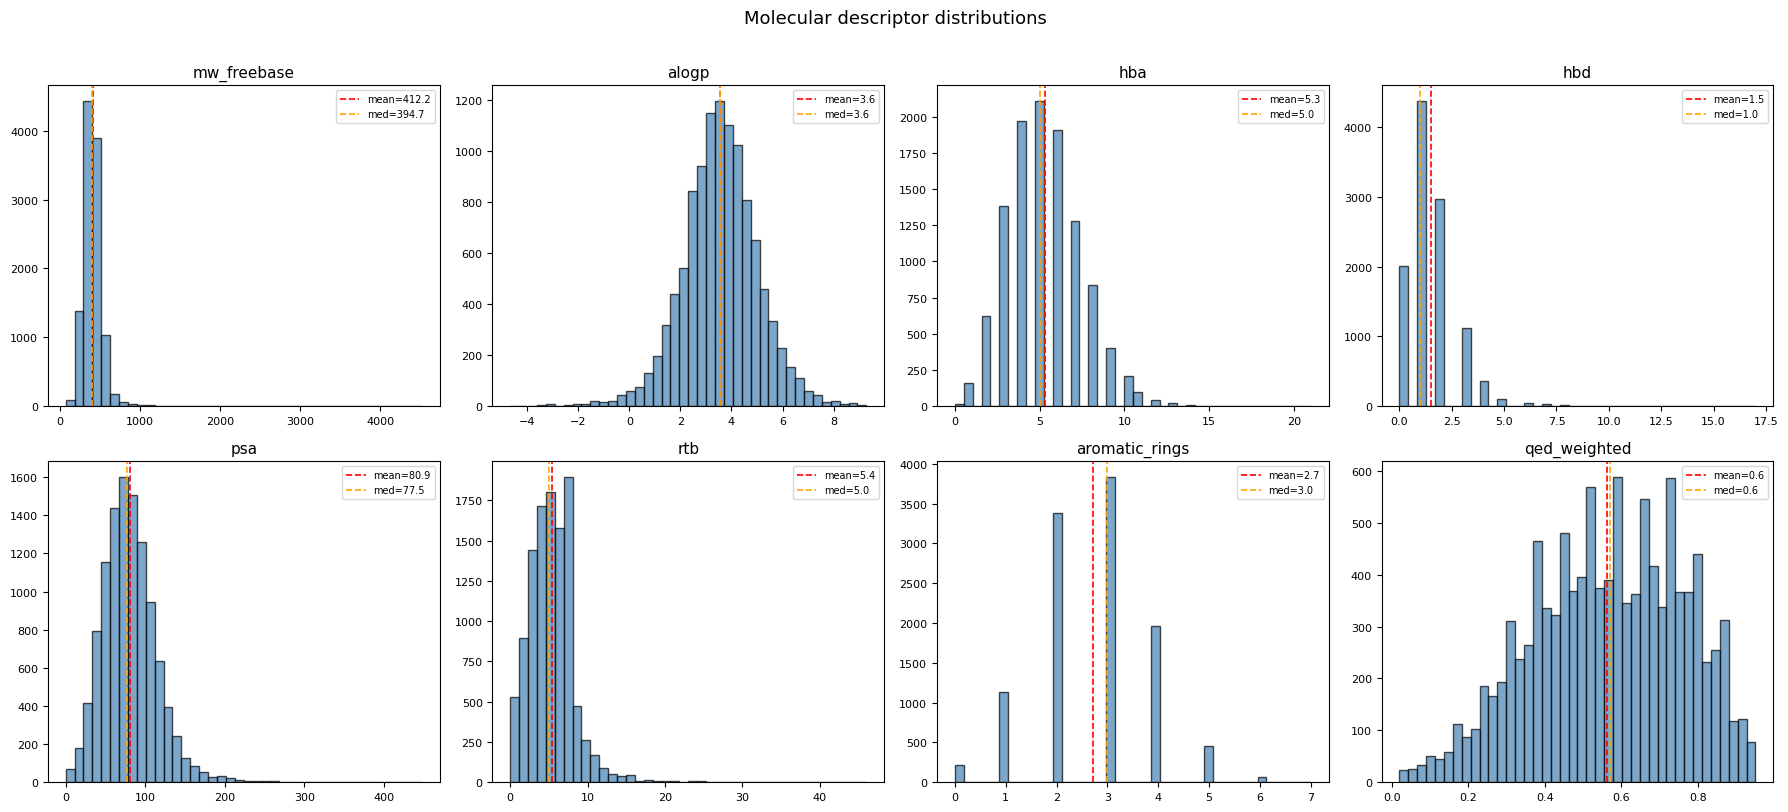

In [57]:
FEATURES = ["mw_freebase", "alogp", "hba", "hbd", "psa", "rtb", "aromatic_rings", "qed_weighted"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    vals = df[col].drop_nulls().to_numpy()
    axes[i].hist(vals, bins=40, color="steelblue", edgecolor="black", alpha=0.7)
    axes[i].axvline(np.mean(vals), color="red", linestyle="--", lw=1.2, label=f"mean={np.mean(vals):.1f}")
    axes[i].axvline(np.median(vals), color="orange", linestyle="--", lw=1.2, label=f"med={np.median(vals):.1f}")
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(fontsize=7)
    axes[i].tick_params(labelsize=8)

plt.suptitle("Molecular descriptor distributions", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 12. Save cleaned data

In [58]:
OUTPUT_PATH = "chembl_36/chembl_36_cleaned.parquet"

df.write_parquet(OUTPUT_PATH)

print(f"Saved cleaned dataset to {OUTPUT_PATH}")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns}")

Saved cleaned dataset to chembl_36/chembl_36_cleaned.parquet
Shape: (11216, 17)
Columns: ['molregno', 'standard_type', 'target_type', 'target_name', 'target_chembl_id', 'molecule_type', 'standard_inchi_key', 'canonical_smiles', 'mw_freebase', 'alogp', 'hba', 'hbd', 'psa', 'rtb', 'aromatic_rings', 'qed_weighted', 'pIC50']
